# US equities panel: the simplest thing that reads a window

[`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb) and
[`08_tabular_dl`](08_tabular_dl.ipynb) all read the same flat table: one row per stock per
session, one column per feature, and nothing in the representation saying the rows are ordered
in time. A model on that table sees the past only through columns somebody computed in advance -
a 21-session momentum, a rolling volatility. It never sees the sequence itself.

A **sequence model** is handed the sequence. Each training example here is a **window**: the 60
most recent sessions of one stock's features, in order, as a matrix of sessions by features -
about three months. The model reads the window and emits one number, the predicted return.

**A window has to be 60 consecutive sessions of the same stock, and on this panel that binds.**
A stock that lists part-way through a fold, halts, or delists leaves a gap, and a window
spanning a gap would treat the two sides as consecutive sessions and read the jump across it as
one day's move. Windows are therefore built only where the sessions are unbroken, which is why
the number of training examples is far smaller than the number of rows and differs between
folds.

**NLinear is deliberately the least elaborate sequence model there is**, and that is why it
comes first. It works one feature at a time. For each feature column of the window it subtracts
that column's last value, maps the 60 sessions to a single number with a linear layer, and adds
the last value back - so each feature is summarised into one number on its own, with no
reference to any other. A final linear layer then combines those per-feature numbers into the
one number the notebook predicts. There is no nonlinearity, no recurrence and no attention
anywhere in it.

It is here as the control the two notebooks after it are read against. A recurrent network and a
mixing architecture are both far more expressive, and expressiveness is only worth its cost if it
buys something a linear map on a normalised window did not already have. This number is what
tells a good result from an easy one.

**The subtract-and-add-back is the whole of the normalisation, and on price-derived features it
matters.** A feature that drifts makes a model reading raw levels spend its capacity tracking
where that series happens to sit rather than how it is moving. Removing each column's last value
before the linear map, and restoring it after, leaves the map looking at the shape of the window
rather than its level.

**Learning objectives.** By the end of this notebook you will be able to:

- Describe what NLinear does to each feature column of a window and how the per-feature results
  become one prediction, and say which part of that is the normalisation.
- Say why the least expressive model in a comparison is the one to run first, and what a result
  from a more elaborate model means without it.
- Explain why a window has to be built from consecutive sessions, and what a window spanning a
  gap would silently claim.
- Read the epoch schedule out of a declared configuration and say how many scoreable models the
  run publishes for it.

**A neural fit has a meaningful state at every epoch**, in the way a boosted model has one at
every iteration and a linear fit does not. An **epoch** is one pass over the training windows.
Each configuration here trains for 100 of them and saves its weights every 5, so it publishes
twenty scoreable models rather than one, each registered with its own identity. The count that
matters downstream is configurations times checkpoints.

**Book reference**: Chapter 13. Chapter 6, Section 6.7 (Search accounting and run logging)
introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices, and
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run per configuration and one complete validation prediction set
per configuration and epoch checkpoint, in `run_log/registry.db` and under `run_log/training/`
and `run_log/predictions/`, grouped under a named population.
[`15_model_analysis`](15_model_analysis.ipynb) compares that population against the other
families and [`16_backtest`](16_backtest.ipynb) backtests every member and selects on validation
backtest Sharpe. **Selection happens there, not here.**

In [1]:
"""Generate NLinear validation predictions through the shared research interface."""

import matplotlib.pyplot as plt
import polars as pl
import yaml

from case_studies.research import (
    candidate_set_supersedes,
    open_study,
    plan_models,
    run_model_population,
    supersedes_for_run,
)
from utils.modeling import load_configs
from utils.paths import get_case_study_dir
from utils.style import FIGSIZE, add_message_title, ml4t_palette, show_with_alt, zero_line

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = ""
CONFIG_NAMES = []
COMMON_OVERRIDES = {}
CONFIG_OVERRIDES = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION = ""
SUPERSEDES_SETS: dict = {}
DEVICE = "cuda"
EXECUTION_TIER = "canonical"
WORKSPACE = ""
PREVIEW_MAX_SYMBOLS = 0
PREVIEW_FOLD_IDS = []
PREVIEW_MAX_TRAIN_SEQUENCES = 0

## 1. Which configurations, and on which label

The menu at `config/training/{label}.yaml` lists the sequence configurations declared for a
label, and this notebook takes the ones whose architecture is `nlinear`. Each name resolves to a
preset holding the full parameter set - here a 60-session lookback, 100 epochs, a checkpoint
every 5, and dropout on the hidden units. The frame below prints the resolved values.

What each setting a run may pass decides:

- **`CONFIG_NAMES`** empty fits every declared `nlinear` configuration. A named subset fits only
  those, which is what to do first: at panel scale a full run is hours, and the point of a first
  pass is to find out whether the plumbing works.
- **`COMMON_OVERRIDES`** changes a parameter for every selected configuration, and
  **`CONFIG_OVERRIDES`** changes one named configuration and takes precedence. An override moves
  a training identity, so an overridden run registers beside the published one rather than
  replacing it.
- **`EXECUTION_TIER`** is `canonical` or `preview`. A canonical run fits every eligible window on
  every fold at the published epoch schedule. A preview run has to declare at least one
  reduction and carries it in the identity, so its results can never be compared against
  canonical ones or reach a holdout decision.

A shortened training schedule is not among the reductions a preview may declare, and
deliberately. This family's preview contract - `SEQUENCE_PREVIEW_FIELDS` in
`case_studies/utils/preview_fields.py` - accepts a narrower universe, a fold subset and a cap on
training sequences, and no epoch count, because a model trained for fewer epochs is a different
model rather than the same one measured sooner. To train a short schedule, pass `n_epochs` in
`COMMON_OVERRIDES`. It moves the training identity, so the result registers beside the published
one, and a run carrying any override publishes neither the canonical population nor the
canonical set names.

In [3]:
case_dir = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((case_dir / "config" / "setup.yaml").read_text())
label = PRIMARY_LABEL or setup["labels"]["primary"]

all_sequence_configs = load_configs(CASE_STUDY_ID, label, family="deep_learning")
published_configs = [
    config
    for config in all_sequence_configs
    if config.get("params", {}).get("architecture") == "nlinear"
]
published_names = [str(config["config_name"]) for config in published_configs]
selected_names = list(CONFIG_NAMES) if CONFIG_NAMES else published_names
unknown_names = sorted(set(selected_names) - set(published_names))
unknown_overrides = sorted(set(CONFIG_OVERRIDES) - set(selected_names))
if not published_names:
    raise ValueError("The published training menu has no NLinear configuration")
if unknown_names:
    raise ValueError(f"Unknown NLinear configurations: {unknown_names}")
if unknown_overrides:
    raise ValueError(f"Overrides supplied for unselected configurations: {unknown_overrides}")
if len(selected_names) != len(set(selected_names)):
    raise ValueError("CONFIG_NAMES contains duplicates")

menu = pl.DataFrame(
    {
        "config_name": [config["config_name"] for config in published_configs],
        "architecture": [config["params"]["architecture"] for config in published_configs],
        "published_params": [str(config.get("params") or {}) for config in published_configs],
        "n_epochs": [config.get("n_epochs") for config in published_configs],
        "checkpoint_interval": [config.get("checkpoint_interval") for config in published_configs],
        "selected": [config["config_name"] in selected_names for config in published_configs],
    }
)
menu

config_name,architecture,published_params,n_epochs,checkpoint_interval,selected
str,str,str,i64,i64,bool
"""nlinear""","""nlinear""","""{'architecture': 'nlinear', 'd…",100,5,true


A run that narrows the selection, overrides a parameter or fits on another device produces a
different set of predictions from the one the canonical name stands for. Publishing it under
that name would leave the name meaning two different member sets at two different times, so the
guard below requires such a run to say what to call its own population, and the frozen set names
in Section 6 are withheld from it for the same reason.

In [4]:
is_published_population = (
    EXECUTION_TIER == "canonical"
    and selected_names == published_names
    and not COMMON_OVERRIDES
    and not CONFIG_OVERRIDES
    and DEVICE == "cuda"
)
if EXECUTION_TIER == "canonical" and not is_published_population and not POPULATION_NAME:
    raise ValueError(
        "this run narrows or overrides what the menu declares, so it cannot publish the canonical "
        "population; pass POPULATION_NAME to give it its own"
    )

Both tiers resolve the study through `open_study`. It reads the labels and features in place
and redirects only writes, so a preview run scores the same inputs a canonical one does and
cannot publish over it. A preview must be given a workspace to write into; a canonical run
leaves `WORKSPACE` empty and regenerates the case study's own artifacts in place.

In [5]:
preview_reductions = {}
if PREVIEW_MAX_SYMBOLS:
    preview_reductions["max_symbols"] = int(PREVIEW_MAX_SYMBOLS)
if PREVIEW_FOLD_IDS:
    preview_reductions["folds"] = [int(fold) for fold in PREVIEW_FOLD_IDS]
if PREVIEW_MAX_TRAIN_SEQUENCES:
    preview_reductions["max_train_sequences"] = int(PREVIEW_MAX_TRAIN_SEQUENCES)

study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 2. Binding the declarations to the data

Each selected NLinear configuration becomes one request with the declared sequence reductions.

In [6]:
requests = []
for config_name in selected_names:
    overrides = {
        "device": DEVICE,
        **COMMON_OVERRIDES,
        **dict(CONFIG_OVERRIDES.get(config_name, {})),
    }
    requests.append(
        study.model(
            family="deep_learning",
            label=label,
            config_name=config_name,
            overrides=overrides,
            execution_tier=EXECUTION_TIER,
            preview_reductions=preview_reductions,
        )
    )
requests = tuple(requests)

request_table = pl.DataFrame(
    {
        "family": [request.family for request in requests],
        "label": [request.label for request in requests],
        "config_name": [request.config_name for request in requests],
        "overrides": [str(request.overrides) for request in requests],
        "execution_tier": [request.execution_tier.value for request in requests],
        "preview_reductions": [str(request.preview_reductions) for request in requests],
    }
)
request_table

family,label,config_name,overrides,execution_tier,preview_reductions
str,str,str,str,str,str
"""deep_learning""","""fwd_ret_1d""","""nlinear""","""{'device': 'cuda'}""","""canonical""","""{}"""


## 3. Planning, then fitting

The planner resolves every training and epoch-checkpoint identity before fitting and writes the
canonical checkpoint population first. Execution builds only sequences that follow the declared
observation calendar and excludes
windows that cross missing expected periods. Each epoch checkpoint stores the fitted
preprocessing state, model weights, predictions, and exact eligible-key evidence. A retry reuses
valid candidate-fold checkpoints and recomputes incomplete work.

In [7]:
plan = plan_models(study, requests=requests)

planned_population = pl.DataFrame(
    {
        "family": [member.family for member in plan.members],
        "config_name": [member.config_name for member in plan.members],
        "checkpoint_kind": [member.checkpoint_kind for member in plan.members],
        "checkpoint_value": [member.checkpoint_value for member in plan.members],
        "training_hash": [member.training_hash for member in plan.members],
        "prediction_hash": [member.prediction_hash for member in plan.members],
    }
)
planned_population

family,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash
str,str,str,i64,str,str
"""deep_learning""","""nlinear""","""epoch""",5,"""9f8942c51a74""","""b51881ba9dac"""
"""deep_learning""","""nlinear""","""epoch""",10,"""9f8942c51a74""","""bc56232447aa"""
"""deep_learning""","""nlinear""","""epoch""",15,"""9f8942c51a74""","""eed1ef4a6d6f"""
"""deep_learning""","""nlinear""","""epoch""",20,"""9f8942c51a74""","""385f123be174"""
"""deep_learning""","""nlinear""","""epoch""",25,"""9f8942c51a74""","""69145d780c7a"""
…,…,…,…,…,…
"""deep_learning""","""nlinear""","""epoch""",80,"""9f8942c51a74""","""3221ce2cd1d9"""
"""deep_learning""","""nlinear""","""epoch""",85,"""9f8942c51a74""","""0196aff15277"""
"""deep_learning""","""nlinear""","""epoch""",90,"""9f8942c51a74""","""8a8c438d1bd9"""


`run_model_population` takes the plan, writes the population down, fits every member and then
checks that what came out is what was declared. The same call serves both tiers: a canonical run
registers an immutable population that the later notebooks bind to, and a preview run gets a
declaration that is verified and then discarded with its workspace, so no notebook here has to
branch on the tier to decide what to publish.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is a set of
prediction identities, so anything that moves a training identity - a changed preset as much as a
changed menu - produces a different population under the same name, and the registry refuses to
write it without being told which snapshot it supersedes. Leaving it empty is right for a first
run and for a reader's clean clone, and `supersedes_for_run` withholds a declared hash wherever
offering it would be refused.

In [8]:
population_name = POPULATION_NAME or "us-equities-nlinear-checkpoints-v1"
execution, official_population = run_model_population(
    study,
    plan,
    population_name=population_name,
    supersedes=supersedes_for_run(
        study,
        population_name=population_name,
        declared=SUPERSEDES_POPULATION,
        execution_tier=EXECUTION_TIER,
    ),
)

print(f"population {official_population.name}: {len(official_population.members)} prediction sets")

Fold-major CV: 16 folds × 1 configs × 60 lookback

  Fold 0: creating sequences...


    train=1,335,547 seq across 1374 symbols
    val=241,035 seq across 1494 symbols
    creating datasets...
    datasets ready
    nlinear:


      epoch   1/100: train_loss=0.018261


      epoch   2/100: train_loss=0.000761


      epoch   3/100: train_loss=0.000756


...

      best_ep=60, IC=+0.0244 (11163.9s, 20 checkpoints)


  nlinear: best_epoch=60, IC=+0.0103 (87738.9s)



  Best: nlinear @ epoch 60 (IC=+0.0103)


  Saved to case_studies/us_equities_panel/run_log/training/9f8942c51a74/diagnostics


population us-equities-nlinear-checkpoints-v1: 20 prediction sets


## 4. What was actually fitted

These rows expose the feature, fold, sequence, runtime, model, and checkpoint settings used by
the runner, including defaults that were not repeated in the notebook parameters.

In [9]:
resolved_rows = []
for run in execution.runs:
    spec = run.training.spec()
    computation = spec["computation"]
    model = computation["model"]
    resolved_rows.append(
        {
            "config_name": spec["config_name"],
            "architecture": model["params"]["architecture"],
            "features": len(computation["feature_names"]),
            "folds": computation["expected_prediction_keys"]["n_folds"],
            "eligible_rows": computation["expected_prediction_keys"]["n_rows"],
            "lookback": model["params"]["lookback"],
            "device": computation["numerics"]["device"],
            "n_epochs": model["params"]["n_epochs"],
            "checkpoints": [item["value"] for item in computation["checkpoint_schedule"]],
            "training_hash": run.training.hash,
        }
    )

resolved_table = pl.DataFrame(resolved_rows).sort("config_name")
resolved_table

config_name,architecture,features,folds,eligible_rows,lookback,device,n_epochs,checkpoints,training_hash
str,str,i64,i64,i64,i64,str,i64,list[i64],str
"""nlinear""","""nlinear""",73,16,6653283,60,"""cuda""",100,"[5, 10, … 100]","""9f8942c51a74"""


## 5. What came out

Each catalog row is one complete validation prediction set for one training identity and epoch.
Downstream notebooks filter these rows with Polars and pass the selected table directly to
backtesting. The hashes remain visible for exact provenance and artifact reads.

In [10]:
catalog_columns = [
    "family",
    "config_name",
    "label",
    "split",
    "checkpoint_kind",
    "checkpoint_value",
    "execution_tier",
    "complete",
    "ic_mean",
    "training_hash",
    "prediction_hash",
]
catalog_rows = execution.catalog_rows.select(
    column for column in catalog_columns if column in execution.catalog_rows.columns
).sort("config_name", "checkpoint_value", "prediction_hash")
catalog_rows

family,config_name,label,split,checkpoint_kind,checkpoint_value,execution_tier,complete,ic_mean,training_hash,prediction_hash
str,str,str,str,str,i64,str,bool,f64,str,str
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",5,"""canonical""",true,0.000165,"""9f8942c51a74""","""b51881ba9dac"""
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",10,"""canonical""",true,0.0004,"""9f8942c51a74""","""bc56232447aa"""
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",15,"""canonical""",true,0.000783,"""9f8942c51a74""","""eed1ef4a6d6f"""
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",20,"""canonical""",true,0.003578,"""9f8942c51a74""","""385f123be174"""
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",25,"""canonical""",true,0.000475,"""9f8942c51a74""","""69145d780c7a"""
…,…,…,…,…,…,…,…,…,…,…
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",80,"""canonical""",true,0.002557,"""9f8942c51a74""","""3221ce2cd1d9"""
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",85,"""canonical""",true,0.003595,"""9f8942c51a74""","""0196aff15277"""
"""deep_learning""","""nlinear""","""fwd_ret_1d""","""validation""","""epoch""",90,"""canonical""",true,0.005899,"""9f8942c51a74""","""8a8c438d1bd9"""


A prediction set can be registered complete and still have scored no dates. Cross-sectional
information coefficient needs a minimum number of names quoted on a date before the ranking on
that date means anything, so a universe whose stocks do not overlap in time yields no scorable
dates and a null IC at every checkpoint while every coverage check passes. That is a run which
reports nothing and looks successful, so it is asserted on rather than left to be noticed.

In [11]:
scored = execution.catalog_rows.select("config_name", "checkpoint_value", "ic_mean", "ic_n_days")
unscored = scored.filter(pl.col("ic_n_days").is_null() | (pl.col("ic_n_days") <= 0))
if not unscored.is_empty():
    raise RuntimeError(f"prediction sets scored no dates: {unscored.to_dicts()}")
scored

config_name,checkpoint_value,ic_mean,ic_n_days
str,i64,f64,f64
"""nlinear""",85,0.003595,4031.0
"""nlinear""",35,0.002639,4031.0
"""nlinear""",60,0.010343,4031.0
"""nlinear""",80,0.002557,4031.0
"""nlinear""",20,0.003578,4031.0
…,…,…,…
"""nlinear""",10,0.0004,4031.0
"""nlinear""",75,0.005192,4031.0
"""nlinear""",50,0.003718,4031.0


### Where more training stopped helping

Each line traces one configuration's validation information coefficient as epochs are added to
it. This is the figure the checkpoint dimension exists to produce, and it separates two things a
single end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training windows at the expense of the validation folds. For a model this small - one linear map per feature
column and no nonlinearity - an interior optimum is evidence that even that much capacity
outruns the number of windows this panel yields.
A line that wanders around zero without trend never had anything to learn, and its highest point
is wherever the noise happened to peak. Both produce a respectable-looking maximum, which is why
the curve rather than the maximum is what to read.

Nothing here selects a checkpoint. Every one of them is registered as its own candidate, and
which one a strategy would use is decided by validation backtest Sharpe in
[`16_backtest`](16_backtest.ipynb).

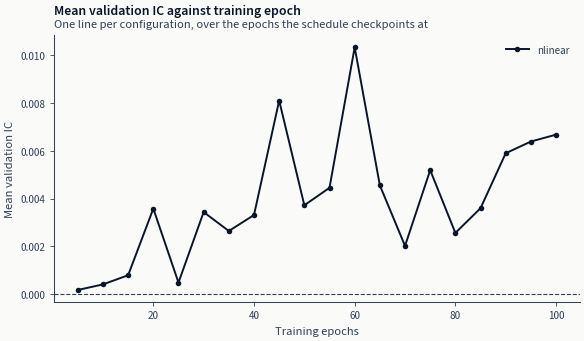

In [12]:
curves = scored.sort("config_name", "checkpoint_value")
config_names = curves.get_column("config_name").unique(maintain_order=True).to_list()
# `ml4t_palette` returns a list of that many colours, so it is called once and indexed.
palette = ml4t_palette(len(config_names), categorical=True)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for index, config_name in enumerate(config_names):
    series = curves.filter(pl.col("config_name") == config_name)
    ax.plot(
        series.get_column("checkpoint_value"),
        series.get_column("ic_mean"),
        marker="o",
        markersize=4,
        lw=1.4,
        color=palette[index],
        label=config_name,
    )
zero_line(ax)
ax.set_xlabel("Training epochs")
ax.set_ylabel("Mean validation IC")
ax.legend(fontsize=8, frameon=False)
add_message_title(
    ax,
    "Mean validation IC against training epoch",
    subtitle="One line per configuration, over the epochs the schedule checkpoints at",
)
# The alt text counts rather than asserts: whether a curve turns over is the question the figure
# exists to answer, and a line described as peaking when it does not is a claim the data refutes.
_peaks = (
    curves.group_by("config_name")
    .agg(
        peak=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first=pl.col("checkpoint_value").min(),
        last=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        interior=pl.col("peak").is_between(pl.col("first"), pl.col("last"), closed="none")
    )
)
_n_interior = int(_peaks.get_column("interior").sum())
show_with_alt(
    fig,
    "A line chart of mean validation information coefficient against training epoch, one line per "
    "configuration, with a dashed line at zero. Counted from the underlying frame, "
    f"{_n_interior} of {_peaks.height} configurations reach their highest information coefficient "
    "at an epoch that is neither the first nor the last, which is what an interior optimum looks "
    "like on this chart.",
)

In [13]:
coverage_rows = []
for run in execution.runs:
    if not run.training.complete:
        raise RuntimeError(f"Incomplete training result: {run.training.hash}")
    for prediction in run.predictions:
        record = prediction.registry_record()
        coverage = prediction.coverage()
        if not prediction.complete or coverage is None or coverage["status"] != "complete":
            raise RuntimeError(f"Incomplete prediction result: {prediction.hash}")
        coverage_rows.append(
            {
                "config_name": run.training.spec()["config_name"],
                "checkpoint": record["checkpoint_value"],
                "training_hash": run.training.hash,
                "prediction_hash": prediction.hash,
                "coverage_status": coverage["status"],
                "expected_rows": coverage["n_expected"],
                "actual_rows": coverage["n_actual"],
                "training_artifacts": len(run.training.artifacts()),
                "prediction_artifacts": len(prediction.artifacts()),
            }
        )

coverage_table = pl.DataFrame(coverage_rows).sort("config_name", "checkpoint")
coverage_table

config_name,checkpoint,training_hash,prediction_hash,coverage_status,expected_rows,actual_rows,training_artifacts,prediction_artifacts
str,i64,str,str,str,i64,i64,i64,i64
"""nlinear""",5,"""9f8942c51a74""","""b51881ba9dac""","""complete""",6653283,6653283,982,1
"""nlinear""",10,"""9f8942c51a74""","""bc56232447aa""","""complete""",6653283,6653283,982,1
"""nlinear""",15,"""9f8942c51a74""","""eed1ef4a6d6f""","""complete""",6653283,6653283,982,1
"""nlinear""",20,"""9f8942c51a74""","""385f123be174""","""complete""",6653283,6653283,982,1
"""nlinear""",25,"""9f8942c51a74""","""69145d780c7a""","""complete""",6653283,6653283,982,1
…,…,…,…,…,…,…,…,…
"""nlinear""",80,"""9f8942c51a74""","""3221ce2cd1d9""","""complete""",6653283,6653283,982,1
"""nlinear""",85,"""9f8942c51a74""","""0196aff15277""","""complete""",6653283,6653283,982,1
"""nlinear""",90,"""9f8942c51a74""","""8a8c438d1bd9""","""complete""",6653283,6653283,982,1


In [14]:
execution_diagnostics = pl.DataFrame(execution.diagnostics)
execution_diagnostics

status,training_hash,reused
str,str,bool
"""completed""","""9f8942c51a74""",false


## 6. Naming the sets the later notebooks open

A canonical default CUDA run freezes what it produced under two stable names, and preview or
customized canonical requests publish neither.

The first name is the **full set**: every prediction row this run returned, which
[`16_backtest`](16_backtest.ipynb) backtests member by member.

The second is the **bounded diagnostic set**, and it is bounded hard.
[`15_model_analysis`](15_model_analysis.ipynb) loads every diagnostic member's raw prediction
frame and holds them all while it joins them pairwise; one frame on this panel is over seven
million rows and about 225 MB in memory, so a set that grew with the checkpoint count would not fit
beside the other seven families'. The bound is the last checkpoint of each published
configuration - one member here, because the menu declares one NLinear configuration. The
epoch dimension is still read, in the learning-curve figure above, which is drawn from registry
metrics rather than from raw frames.

In [15]:
set_rows = []
if is_published_population:
    label_name = label.replace("_", "-")
    full_set_name = f"us-equities-{label_name}-nlinear-v1"
    full_set = study.predictions.freeze(
        execution.catalog_rows,
        name=full_set_name,
        supersedes=candidate_set_supersedes(
            study, name=full_set_name, declared=SUPERSEDES_SETS.get(full_set_name, "")
        ),
    )
    diagnostic_rows = execution.catalog_rows.filter(
        # `.fill_null(True)` covers a family that publishes no checkpoint value at all, where the
        # comparison is null rather than false and would otherwise empty the frame.
        (
            pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("config_name")
        ).fill_null(True)
    )
    diagnostic_set_name = f"us-equities-{label_name}-nlinear-diagnostics-v1"
    diagnostic_set = study.predictions.freeze(
        diagnostic_rows,
        name=diagnostic_set_name,
        supersedes=candidate_set_supersedes(
            study, name=diagnostic_set_name, declared=SUPERSEDES_SETS.get(diagnostic_set_name, "")
        ),
    )
    set_rows = [
        {
            "role": "backtest population",
            "set_name": full_set.name,
            "members": len(full_set.members),
        },
        {
            "role": "bounded diagnostics",
            "set_name": diagnostic_set.name,
            "members": len(diagnostic_set.members),
        },
    ]
compatible_sets = pl.DataFrame(
    set_rows,
    schema={"role": pl.String, "set_name": pl.String, "members": pl.Int64},
)
compatible_sets

role,set_name,members
str,str,i64
"""backtest population""","""us-equities-fwd-ret-1d-nlinear…",20
"""bounded diagnostics""","""us-equities-fwd-ret-1d-nlinear…",1


`15_model_analysis` reopens both names: the full set to confirm the run filled every member it
promised, and the diagnostic set to read raw predictions. `16_backtest` passes every full-set
catalog row to the shared backtest runner. Neither the metrics here nor the ones there choose a
configuration or a checkpoint; selection is on validation backtest Sharpe in `16_backtest`.

## What to notice

**This is the number the next two notebooks are measured against.** NLinear has one linear map
and no nonlinearity, so whatever it reaches is what a window contains before any architecture is
brought to bear on it. A recurrent or mixing model that does not clear it has not shown that its
extra capacity found anything.

**A checkpoint is part of a configuration, not a detail of how it was fitted.** Twenty
checkpoints per configuration are twenty candidates, each registered separately, because keeping
each configuration's own best epoch after seeing the results would report the maximum of twenty
numbers as though it were one.

**Known limitations.** Every window is built from consecutive sessions, so a stock's history
around a halt or a listing contributes nothing and the training set is not a uniform sample of
the panel. What is measured is ranking accuracy on validation folds that have been read many
times over by the time a case study reaches this notebook, and it says nothing about what a
strategy trading those rankings would earn after costs.

**Next**: [`10_dl_lstm`](10_dl_lstm.ipynb) gives the same windows to a model that carries state
across them.